In [54]:
import geopandas as gpd
import numpy as np
import pandas as pd
import shapely
import matplotlib.pyplot as plt

from src.constants import (
    CA_NAD83_Albers,
    CULVER_CITY_FEED_KEY,
    SERVICE_DATE,
    SHAPE_KEY_TO_SHAPE_ID_MAP,
    MAX_SNAP_DISTANCE_M,
)
from src._data_loaders import (
    get_selected_shapes,
    get_traffic_signals,
    list_available_service_dates,
)

from src.match_shapes_vp import project_points_on_shape

In [55]:
# for caltrans network only

import os

#os.environ["REQUESTS_CA_BUNDLE"] = r"C:\Users\s163107\Documents\CTROOTCA01.cer"

In [56]:
SHAPE_KEY = "105"
SHAPE_ID = SHAPE_KEY_TO_SHAPE_ID_MAP[SHAPE_KEY]
SEGMENT_START_SIGNAL = 28
SEGMENT_END_SIGNAL = SEGMENT_START_SIGNAL + 1
SEGMENT_BUFFER_LENGTH = 50
SPEED_BUCKET_MPH = 4
METERS_PER_SECOND_TO_MPH = 2.23694

In [57]:
from src._data_loaders import get_smoothed_vehicle_positions


service_dates = list_available_service_dates()
smoothed_vehicle_positions = get_smoothed_vehicle_positions(service_date=SERVICE_DATE, shape_id=SHAPE_ID)

shapes = get_selected_shapes(SERVICE_DATE, CULVER_CITY_FEED_KEY, [SHAPE_ID])
signals = get_traffic_signals()
stops = gpd.read_file(f"data/stops_{SHAPE_ID}.geojson").to_crs(CA_NAD83_Albers)

In [58]:
shape = shapes.iloc[0]  # TODO: everything should assume a single shape here

# Distance along the full shape where each bounding signal sits
signal_distances = project_points_on_shape(signals.geometry, shapes.geometry, MAX_SNAP_DISTANCE_M)
start_signal_distance = signal_distances.loc[SEGMENT_START_SIGNAL]
end_signal_distance = signal_distances.loc[SEGMENT_END_SIGNAL]

# Segment runs between the two signals, with a buffer on each side
start_segment_distance = start_signal_distance - SEGMENT_BUFFER_LENGTH
end_segment_distance = end_signal_distance + SEGMENT_BUFFER_LENGTH
segment_length = end_signal_distance - start_signal_distance

In [59]:
# Limit the smoothed trajectories to this segment and re-reference distances so
# that 0 = start signal (negative values fall in the upstream buffer).
in_segment = smoothed_vehicle_positions["distance_along_shape_smoothed"].between(
    start_segment_distance, end_segment_distance
)
smoothed_in_segment = smoothed_vehicle_positions.loc[in_segment].assign(
    distance_along_segment=lambda smoothed: smoothed["distance_along_shape_smoothed"] - start_signal_distance
)

start signal at 0 m, end signal at 275 m
1 stop(s) in segment at: [20.3] m


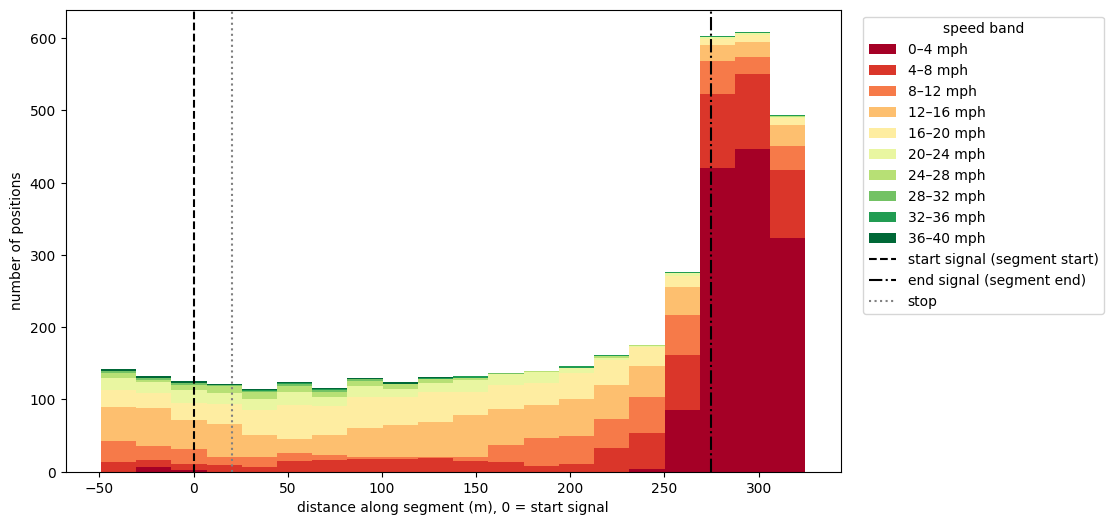

In [60]:
# Reference the stops to the same coordinate system (0 = start signal)
stop_distances = project_points_on_shape(stops, shapes.geometry, MAX_SNAP_DISTANCE_M) - start_signal_distance
stops_in_segment = stop_distances[
    (stop_distances >= -SEGMENT_BUFFER_LENGTH) & (stop_distances <= segment_length + SEGMENT_BUFFER_LENGTH)
]
print(f"start signal at 0 m, end signal at {segment_length:.0f} m")
print(f"{len(stops_in_segment)} stop(s) in segment at: {stops_in_segment.round(1).to_list()} m")

# Bucket each smoothed position's speed into SPEED_BUCKET_MPH-wide bands
speed_mph = smoothed_in_segment["speed_m_per_s"] * METERS_PER_SECOND_TO_MPH
speed_bucket_edges = np.arange(
    np.floor(speed_mph.min() / SPEED_BUCKET_MPH) * SPEED_BUCKET_MPH,
    np.ceil(speed_mph.max() / SPEED_BUCKET_MPH) * SPEED_BUCKET_MPH + SPEED_BUCKET_MPH,
    SPEED_BUCKET_MPH,
)
speed_bucket = pd.cut(speed_mph, bins=speed_bucket_edges, right=False)

# Stacked histogram: distance along segment (x), position count (y), speed band (color).
# Slow bands are red and fast bands green so congestion stands out.
distances_per_speed_bucket = [
    smoothed_in_segment.loc[speed_bucket == bucket, "distance_along_segment"]
    for bucket in speed_bucket.cat.categories
]
speed_bucket_labels = [
    f"{interval.left:.0f}–{interval.right:.0f} mph" for interval in speed_bucket.cat.categories
]
speed_bucket_colors = list(plt.cm.RdYlGn(np.linspace(0, 1, len(speed_bucket.cat.categories))))

# Positions with no computed speed get their own band so they aren't dropped
unknown_speed_distances = smoothed_in_segment.loc[speed_mph.isna(), "distance_along_segment"]
if not unknown_speed_distances.empty:
    distances_per_speed_bucket.append(unknown_speed_distances)
    speed_bucket_labels.append("unknown")
    speed_bucket_colors.append("lightgray")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    distances_per_speed_bucket,
    bins=20,
    stacked=True,
    color=speed_bucket_colors,
    label=speed_bucket_labels,
)
ax.axvline(0, color="black", linestyle="--", label="start signal (segment start)")
ax.axvline(segment_length, color="black", linestyle="-.", label="end signal (segment end)")
for i, stop_distance in enumerate(stops_in_segment):
    ax.axvline(stop_distance, color="gray", linestyle=":", label="stop" if i == 0 else None)
ax.set_xlabel("distance along segment (m), 0 = start signal")
ax.set_ylabel("number of positions")
ax.legend(title="speed band", bbox_to_anchor=(1.02, 1), loc="upper left")

In [61]:
smoothed_in_segment

,service_date,shape_id,TRIP_KEY,event_time_datetime,distance_along_shape_smoothed,speed_m_per_s,distance_along_segment
720865,2026-02-03,shp-1-05,49.0,2026-02-03 06:13:35,5090.111624,6.772538,-46.781421
720866,2026-02-03,shp-1-05,49.0,2026-02-03 06:13:36,5096.872675,6.753059,-40.020370
720867,2026-02-03,shp-1-05,49.0,2026-02-03 06:13:37,5103.617742,6.740569,-33.275304
720868,2026-02-03,shp-1-05,49.0,2026-02-03 06:13:38,5110.353814,6.735070,-26.539232
720869,2026-02-03,shp-1-05,49.0,2026-02-03 06:13:39,5117.087881,6.736560,-19.805164
...,...,...,...,...,...,...,...
981876,2026-02-03,shp-1-05,1553.0,2026-02-03 22:16:57,5454.561474,1.452746,317.668429
981877,2026-02-03,shp-1-05,1553.0,2026-02-03 22:16:58,5456.027350,1.482133,319.134304
981878,2026-02-03,shp-1-05,1553.0,2026-02-03 22:16:59,5457.525741,1.517777,320.632695
981879,2026-02-03,shp-1-05,1553.0,2026-02-03 22:17:00,5459.062903,1.559677,322.169858


In [62]:
# Map of the segment alone
segment_geometry = shapely.ops.substring(shape.geometry, start_segment_distance, end_segment_distance)
segment = gpd.GeoSeries([segment_geometry], crs=shapes.crs)
segment.explore()